# Denoising Diffusion Probabilistic Models (DDPM)

Replication of Ho, Jain and Abbeel (2020), *Denoising Diffusion Probabilistic Models*
(arXiv:2006.11239).

A diffusion model defines a fixed forward process that gradually corrupts data into Gaussian
noise over many timesteps, and trains a neural network to reverse it by predicting the noise
added at each step. Generation then starts from pure noise and iteratively denoises. We
implement the simplified training objective from the paper (predict the noise with an MSE
loss) using a small time-conditioned U-Net, train it on MNIST, and reproduce the key result:
sampling the reverse process turns random noise into recognizable handwritten digits.

In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("running on:", torch.cuda.get_device_name(0) if device == "cuda" else "cpu")

running on: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# MNIST scaled to [-1, 1] and padded to 32x32 for clean down/upsampling.
tf = T.Compose([T.Resize(32), T.ToTensor(), T.Normalize((0.5,), (0.5,))])
train = tv.datasets.MNIST("../data", train=True, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True, drop_last=True)
print("train", len(train))

train

 60000


In [3]:
# Forward-process schedule (linear betas), with the closed-form q(x_t | x_0) coefficients.
TT = 200
betas = torch.linspace(1e-4, 0.02, TT, device=device)
alphas = 1 - betas
acp = torch.cumprod(alphas, 0)                       # alpha-bar_t
sqrt_acp = acp.sqrt(); sqrt_1macp = (1 - acp).sqrt()

def q_sample(x0, t, noise):
    return sqrt_acp[t][:, None, None, None] * x0 + sqrt_1macp[t][:, None, None, None] * noise
print("timesteps:", TT)

timesteps: 200


In [4]:
def time_embed(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    a = t[:, None].float() * freqs[None]
    return torch.cat([a.sin(), a.cos()], -1)

class ResBlock(nn.Module):
    def __init__(self, cin, cout, tdim):
        super().__init__()
        self.n1 = nn.GroupNorm(8, cin); self.c1 = nn.Conv2d(cin, cout, 3, 1, 1)
        self.temb = nn.Linear(tdim, cout)
        self.n2 = nn.GroupNorm(8, cout); self.c2 = nn.Conv2d(cout, cout, 3, 1, 1)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()
    def forward(self, x, t):
        h = self.c1(F.silu(self.n1(x)))
        h = h + self.temb(t)[:, :, None, None]
        h = self.c2(F.silu(self.n2(h)))
        return h + self.skip(x)

In [5]:
class UNet(nn.Module):
    def __init__(self, base=32, tdim=128):
        super().__init__()
        self.tdim = tdim
        self.tmlp = nn.Sequential(nn.Linear(tdim, tdim), nn.SiLU(), nn.Linear(tdim, tdim))
        self.init = nn.Conv2d(1, base, 3, 1, 1)
        self.d1 = ResBlock(base, base, tdim);       self.down1 = nn.Conv2d(base, base, 4, 2, 1)
        self.d2 = ResBlock(base, 2*base, tdim);     self.down2 = nn.Conv2d(2*base, 2*base, 4, 2, 1)
        self.mid = ResBlock(2*base, 2*base, tdim)
        self.upc2 = nn.ConvTranspose2d(2*base, 2*base, 4, 2, 1); self.up2 = ResBlock(2*base + 2*base, 2*base, tdim)
        self.upc1 = nn.ConvTranspose2d(2*base, base, 4, 2, 1);    self.up1 = ResBlock(base + base, base, tdim)
        self.out = nn.Sequential(nn.GroupNorm(8, base), nn.SiLU(), nn.Conv2d(base, 1, 3, 1, 1))
    def forward(self, x, t):
        te = self.tmlp(time_embed(t, self.tdim))
        x0 = self.init(x)                                   # 32x32
        h1 = self.d1(x0, te)                                 # 32x32
        h2 = self.d2(self.down1(h1), te)                     # 16x16
        m = self.mid(self.down2(h2), te)                     # 8x8
        u = self.upc2(m)                                     # 16x16
        u = self.up2(torch.cat([u, h2], 1), te)
        u = self.upc1(u)                                     # 32x32
        u = self.up1(torch.cat([u, h1], 1), te)
        return self.out(u)

net = UNet().to(device)
print("U-Net parameters:", sum(p.numel() for p in net.parameters()))

U-Net parameters: 546945


In [6]:
opt = torch.optim.Adam(net.parameters(), lr=2e-4)
for ep in range(20):                                  # GPU makes a longer schedule cheap
    net.train(); running = 0.0
    for x, _ in train_dl:
        x = x.to(device)
        t = torch.randint(0, TT, (x.size(0),), device=device)
        noise = torch.randn_like(x)
        pred = net(q_sample(x, t, noise), t)             # predict the added noise
        loss = F.mse_loss(pred, noise)
        opt.zero_grad(); loss.backward(); opt.step(); running += loss.item()
    print(f"epoch {ep+1}: noise-prediction MSE = {running/len(train_dl):.4f}")

epoch 1: noise-prediction MSE = 0.1099


epoch 2: noise-prediction MSE = 0.0532


epoch 3: noise-prediction MSE = 0.0469


epoch 4: noise-prediction MSE = 0.0440


epoch 5: noise-prediction MSE = 0.0417


...

epoch 16: noise-prediction MSE = 0.0346


epoch 17: noise-prediction MSE = 0.0342


epoch 18: noise-prediction MSE = 0.0338


epoch 19: noise-prediction MSE = 0.0338


epoch 20: noise-prediction MSE = 0.0335


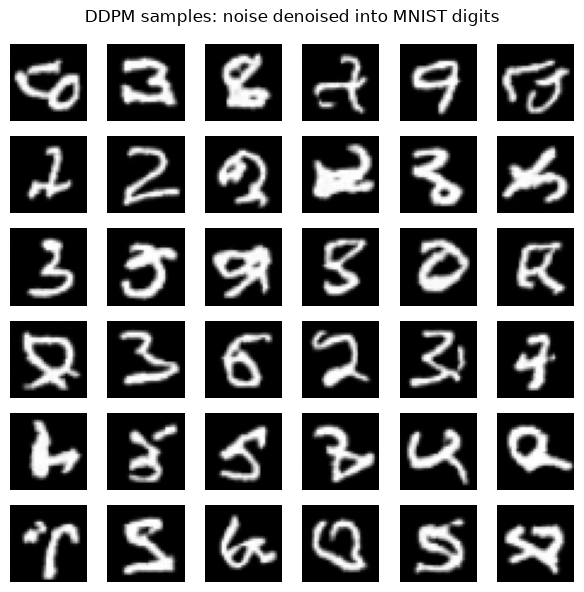

In [7]:
# Ancestral sampling: start from noise and run the learned reverse process.
@torch.no_grad()
def sample(nimg=36):
    net.eval(); x = torch.randn(nimg, 1, 32, 32, device=device)
    for ti in reversed(range(TT)):
        t = torch.full((nimg,), ti, dtype=torch.long, device=device)
        eps = net(x, t)
        mean = (1/alphas[ti].sqrt()) * (x - betas[ti]/sqrt_1macp[ti] * eps)
        x = mean + (betas[ti].sqrt() * torch.randn_like(x) if ti > 0 else 0)
    return x.clamp(-1, 1)

imgs = sample(36).cpu()                               # back to CPU for plotting
fig, ax = plt.subplots(6, 6, figsize=(6, 6))
for i, a in enumerate(ax.flat):
    a.imshow(imgs[i, 0], cmap="gray"); a.axis("off")
plt.suptitle("DDPM samples: noise denoised into MNIST digits"); plt.tight_layout(); plt.show()